# Model Evaluation, Visualisation and Reporting

This notebook is a **pure reporting layer** — it loads persisted outputs from
all upstream notebooks and consolidates evaluation in one place. No models
are re-trained here.

| Section | Content |
|---------|--------|
| 3 | Classification summary — unified metrics, confusion matrix grid, macro F1 comparison |
| 4 | Misclassification analysis — Fatal class deep-dive |
| 5 | Regression summary — metrics table, residuals, trend, spatial delta |
| 6 | Clustering summary — silhouette/DB table, DBSCAN stats, cluster profiles, maps |
| 7 | Responsible AI — subgroup bias audit, documented limitations, improvement strategies |

---
# 1. Configuration and Imports

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings('ignore')


def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')


ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'
STAGE_DIR = NOTEBOOKS_DIR / 'stage_outputs'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':    nb_cfg['plotting']['figsize_wide'],
    'figsize_square':  nb_cfg['plotting']['figsize_square'],
    'figsize_tall':    nb_cfg['plotting']['figsize_tall'],
    'palette':         nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load All Stage Outputs

In [2]:
with open(STAGE_DIR / 'stage3.pkl', 'rb') as f:
    s3 = pickle.load(f)  # multiclass

with open(STAGE_DIR / 'stage4.pkl', 'rb') as f:
    s4 = pickle.load(f)  # binary

with open(STAGE_DIR / 'stage5.pkl', 'rb') as f:
    s5 = pickle.load(f)  # categorical

with open(STAGE_DIR / 'regression.pkl', 'rb') as f:
    reg = pickle.load(f)

with open(STAGE_DIR / 'unsupervised.pkl', 'rb') as f:
    unsup = pickle.load(f)

print('All stage outputs loaded.')
print(f'  Stage 3 models: {list(s3["results"].keys())}')
print(f'  Stage 4 models: {list(s4["results"].keys())}')
print(f'  Stage 5 models: {list(s5["results"].keys())}')
print('  Regression tasks: task_a, task_b, task_c')
print('  Unsupervised tasks: task_a, task_b')

All stage outputs loaded.
  Stage 3 models: ['Logistic Regression', 'Random Forest', 'XGBoost']
  Stage 4 models: ['Logistic Regression', 'Random Forest', 'XGBoost']
  Stage 5 models: ['Logistic Regression', 'Random Forest', 'XGBoost']
  Regression tasks: task_a, task_b, task_c
  Unsupervised tasks: task_a, task_b


---
# 3. Classification Summary

Stages 3, 4, and 5 each trained Logistic Regression, Random Forest, and XGBoost
on a different classification task. Results are consolidated here for cross-task
and cross-model comparison.

## 3.1 Unified Metrics Table

In [3]:
# Build unified metrics table across all 9 classifiers (3 models x 3 tasks)
rows = []
for stage, label in [(s3, 'Multiclass'), (s4, 'Binary'), (s5, 'Categorical')]:
    for model_name, r in stage['results'].items():
        row = {
            'Task':        label,
            'Target':      stage['target_col'],
            'Model':       model_name,
            'Accuracy':    round(r['accuracy'],    4),
            'Weighted F1': round(r['f1_weighted'], 4),
            'Macro F1':    round(r['f1_macro'],    4),
        }
        for cls_name, f1 in zip(stage['class_names'], r['f1_per_class'], strict=False):
            row[f'F1 ({cls_name})'] = round(f1, 4)
        rows.append(row)

clf_summary = pd.DataFrame(rows)
print('Unified classification metrics (all 9 models):')
clf_summary.set_index(['Task', 'Model'])

Unified classification metrics (all 9 models):


Target  Accuracy  Weighted F1  \
Task        Model                                                             
Multiclass  Logistic Regression   collision_severity    0.5028       0.5858   
            Random Forest         collision_severity    0.7700       0.7523   
            XGBoost               collision_severity    0.7624       0.7465   
Binary      Logistic Regression  urban_or_rural_area    0.8602       0.8926   
            Random Forest        urban_or_rural_area    0.8836       0.9069   
            XGBoost              urban_or_rural_area    0.8829       0.9067   
Categorical Logistic Regression      junction_detail    0.4814       0.5195   
            Random Forest            junction_detail    0.5255       0.5626   
            XGBoost                  junction_detail    0.5275       0.5656   

                                 Macro F1  F1 (Fatal)  F1 (Serious)  \
Task        Model                                                     
Multiclass  Logistic Regression    0.3036      0.0407        0.2058   
            Random Forest          0.3502      0.0000        0.1813   
            XGBoost                0.3454      0.0000        0.1722   
Binary      Logistic Regression    0.6147         NaN           NaN   
            Random Forest          0.6315         NaN           NaN   
            XGBoost                0.6333         NaN           NaN   
Categorical Logistic Regression    0.2851         NaN           NaN   
            Random Forest          0.3026         NaN           NaN   
            XGBoost                0.3073         NaN           NaN   

                                 F1 (Slight)  F1 (0)  F1 (1)  F1 (13)  \
Task        Model                                                       
Multiclass  Logistic Regression       0.6643     NaN     NaN      NaN   
            Random Forest             0.8692     NaN     NaN      NaN   
            XGBoost                   0.8639     NaN     NaN      NaN   
Binary      Logistic Regression          NaN  0.9223  0.3072      NaN   
            Random Forest                NaN  0.9363  0.3267      NaN   
            XGBoost                      NaN  0.9358  0.3307      NaN   
Categorical Logistic Regression          NaN  0.9418     NaN   0.3305   
            Random Forest                NaN  0.9930     NaN   0.3548   
            XGBoost                      NaN  0.9938     NaN   0.3558   

                                 F1 (16)  F1 (17)  F1 (18)  F1 (19)  
Task        Model                                                    
Multiclass  Logistic Regression      NaN      NaN      NaN      NaN  
            Random Forest            NaN      NaN      NaN      NaN  
            XGBoost                  NaN      NaN      NaN      NaN  
Binary      Logistic Regression      NaN      NaN      NaN      NaN  
            Random Forest            NaN      NaN      NaN      NaN  
            XGBoost                  NaN      NaN      NaN      NaN  
Categorical Logistic Regression   0.1212   0.1481   0.0635   0.1053  
            Random Forest         0.2453   0.0704   0.0806   0.0714  
            XGBoost               0.2587   0.0822   0.0798   0.0735

## 3.2 Macro F1 by Task and Model

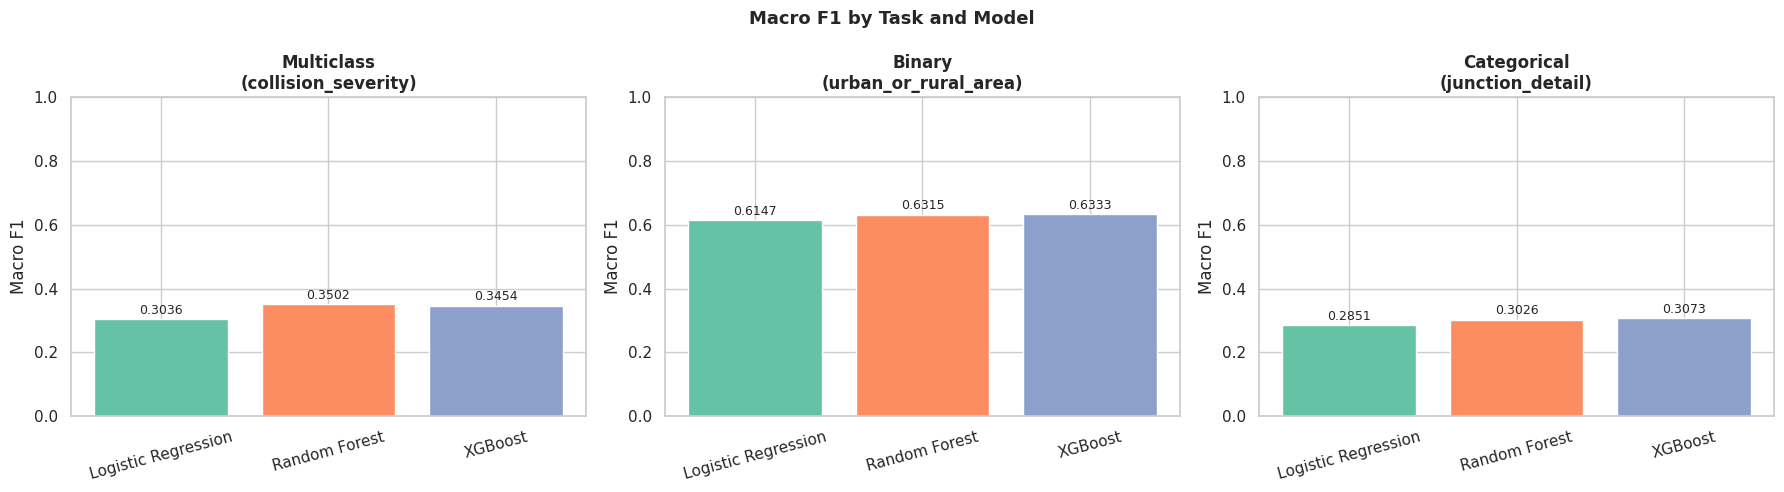

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette(NB_CONFIG['palette'], 3)
model_names = list(s3['results'].keys())

for ax, (stage, label) in zip(axes, [(s3, 'Multiclass'), (s4, 'Binary'), (s5, 'Categorical')], strict=False):
    macros = [stage['results'][m]['f1_macro'] for m in model_names]
    bars = ax.bar(model_names, macros, color=palette, edgecolor='white')
    for bar, val in zip(bars, macros, strict=False):
        ax.annotate(f'{val:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=9)
    ax.set_title(f'{label}\n({stage["target_col"]})', fontweight='bold')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Macro F1 by Task and Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3 Confusion Matrix Grid

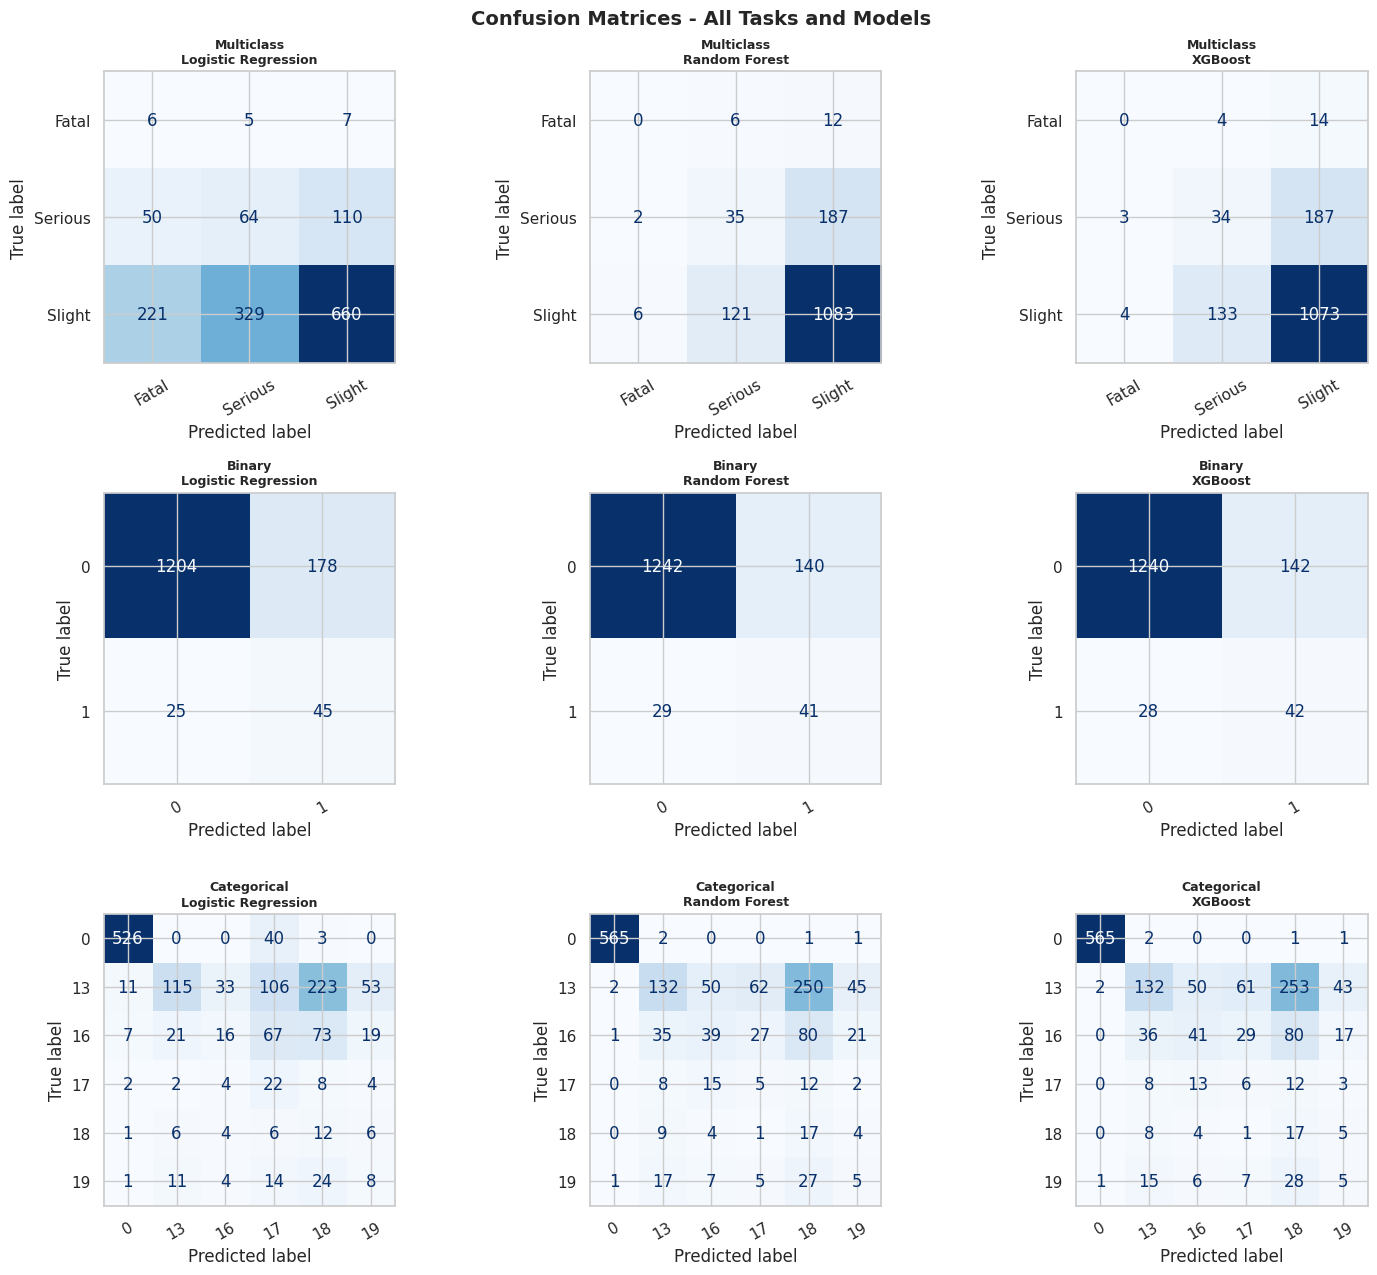

In [5]:
# 3x3 confusion matrix grid: rows=tasks, cols=models
model_names = list(s3['results'].keys())
stages      = [
    (s3, 'Multiclass'),
    (s4, 'Binary'),
    (s5, 'Categorical'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for row_idx, (stage, task_label) in enumerate(stages):
    for col_idx, model_name in enumerate(model_names):
        ax  = axes[row_idx][col_idx]
        r   = stage['results'][model_name]
        cm  = confusion_matrix(stage['y_test'], r['y_pred'])
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=stage['class_names']
        )
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{task_label}\n{model_name}', fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)

fig.suptitle('Confusion Matrices - All Tasks and Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 4. Misclassification Analysis

The Fatal class (`collision_severity=1`) is the most safety-critical and the
hardest to classify due to its rarity (~1.2% of records). This section identifies
Fatal collisions that all three multiclass models failed to detect, and profiles
their feature values against those that at least one model correctly identified.

## 4.1 Fatal Class Recall Per Model

In [6]:
# Focus: multiclass task, Fatal class (label=1)
# Identify Fatal collisions that ALL three models misclassified
y_test_mc   = s3['y_test']
X_test_mc   = s3['X_test']
model_names = list(s3['results'].keys())

preds = {m: s3['results'][m]['y_pred'] for m in model_names}

# Records where true label is Fatal (1)
fatal_mask = y_test_mc.values == 1
fatal_idx  = np.where(fatal_mask)[0]

# Among Fatal records, find those misclassified by ALL models
all_wrong_mask = np.array([
    all(preds[m][i] != 1 for m in model_names)
    for i in fatal_idx
])

n_fatal        = fatal_mask.sum()
n_all_wrong    = all_wrong_mask.sum()
n_any_correct  = (~all_wrong_mask).sum()

print(f'Fatal records in test set:              {n_fatal}')
print(f'Misclassified by ALL three models:      {n_all_wrong} ({n_all_wrong/n_fatal:.1%})')
print(f'Correctly identified by at least one:   {n_any_correct} ({n_any_correct/n_fatal:.1%})')
print()

# Per-model Fatal recall
for m in model_names:
    fatal_pred = preds[m][fatal_mask]
    recall = (fatal_pred == 1).sum() / n_fatal
    print(f'{m:25s} Fatal recall: {recall:.1%}  ({(fatal_pred==1).sum()}/{n_fatal})')

Fatal records in test set:              18
Misclassified by ALL three models:      12 (66.7%)
Correctly identified by at least one:   6 (33.3%)

Logistic Regression       Fatal recall: 33.3%  (6/18)
Random Forest             Fatal recall: 0.0%  (0/18)
XGBoost                   Fatal recall: 0.0%  (0/18)


## 4.2 Feature Profile of Missed vs Identified Fatal Collisions

In [7]:
# Compare features of: correctly-identified Fatal vs all-wrong Fatal
X_fatal = X_test_mc.iloc[fatal_idx].copy()
X_fatal['all_models_wrong'] = all_wrong_mask

correct_profile = X_fatal[~all_wrong_mask].mean()
wrong_profile   = X_fatal[all_wrong_mask].mean()

profile_df = pd.DataFrame({
    'Correctly identified (>=1 model)': correct_profile,
    'Missed by all models':             wrong_profile,
}).T.round(3)

print('Feature profile - Fatal collisions correctly identified vs missed by all models:')
profile_df

Feature profile - Fatal collisions correctly identified vs missed by all models:


,collision_year,location_easting_osgr,location_northing_osgr,number_of_vehicles,number_of_casualties,day_of_week,first_road_class,first_road_number,road_type,speed_limit,...,special_conditions_at_site,carriageway_hazards,did_police_officer_attend_scene_of_accident,trunk_road_flag,hour_of_day,month,is_weekend,time_period,multi_vehicle,all_models_wrong
Correctly identified (>=1 model),1988.833,0.865,1.000,0.5,1.0,5.000,3.000,1142.667,4.00,48.333,...,0.0,0.0,-1.0,1.833,15.167,7.167,0.00,1.167,0.0,0.0
Missed by all models,1994.500,0.996,0.928,0.5,1.0,3.583,4.833,1542.917,5.75,30.833,...,0.0,0.0,-0.5,2.000,14.667,7.833,0.25,1.500,0.0,1.0


## 4.3 Top Distinguishing Features

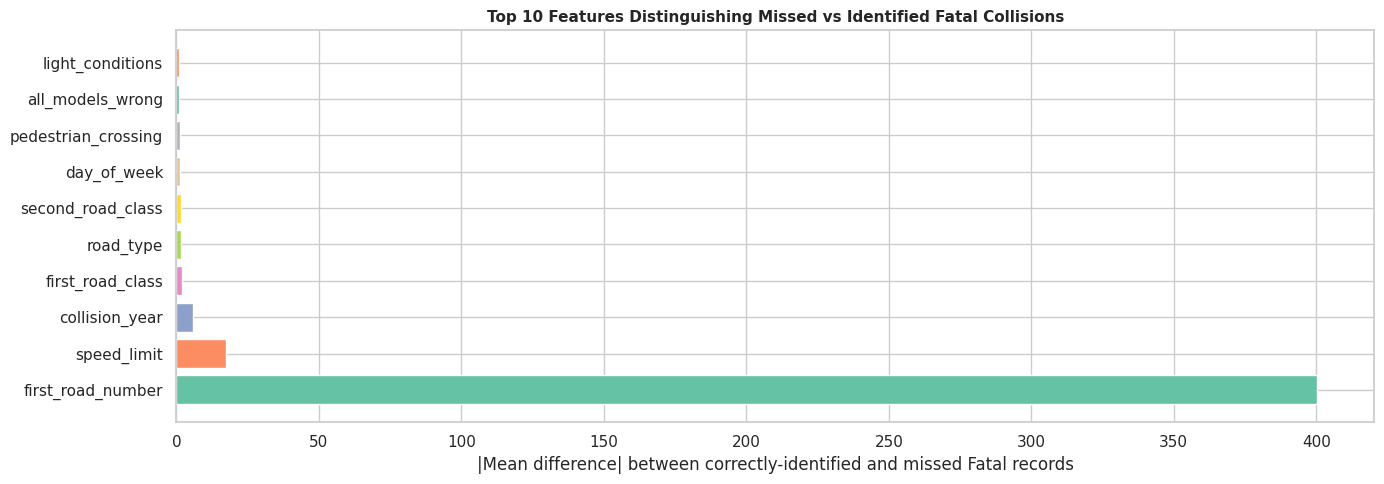

In [8]:
# Highlight the features with the largest mean difference between groups
diffs = (wrong_profile - correct_profile).abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_wide']))
colors = sns.color_palette(NB_CONFIG['palette'], len(diffs))
ax.barh(diffs.index, diffs.values, color=colors, edgecolor='white')
ax.set_xlabel('|Mean difference| between correctly-identified and missed Fatal records')
ax.set_title('Top 10 Features Distinguishing Missed vs Identified Fatal Collisions',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 5. Regression Summary

Task A predicted `number_of_casualties` using road and environment features.
Task B modelled collision frequency over time. Task C augmented Task A with
spatial coordinates to assess whether location improves predictions.

## 5.1 Metrics Table

In [9]:
# Unified regression metrics table
reg_rows = []
for model_name, r in reg['task_a']['results'].items():
    reg_rows.append({
        'Task': 'A (casualties)',
        'Model': model_name,
        'MAE':  round(r['MAE'],  4),
        'RMSE': round(r['RMSE'], 4),
        'R2':   round(r['R2'],   4),
    })
for model_name, r in reg['task_c']['results'].items():
    reg_rows.append({
        'Task': 'C (casualties + spatial)',
        'Model': model_name,
        'MAE':  round(r['MAE'],  4),
        'RMSE': round(r['RMSE'], 4),
        'R2':   round(r['R2'],   4),
    })

reg_summary = pd.DataFrame(reg_rows).set_index(['Task', 'Model'])
print('Regression metrics (original casualty units):')
reg_summary

Regression metrics (original casualty units):


MAE  RMSE   R2
Task                     Model                            
A (casualties)           Linear Regression  0.0   0.0  1.0
                         Ridge              0.0   0.0  1.0
                         Random Forest      0.0   0.0  0.0
                         XGBoost            0.0   0.0  1.0
C (casualties + spatial) RF + Spatial       0.0   0.0  0.0
                         XGB + Spatial      0.0   0.0  1.0

## 5.2 Residual Distributions

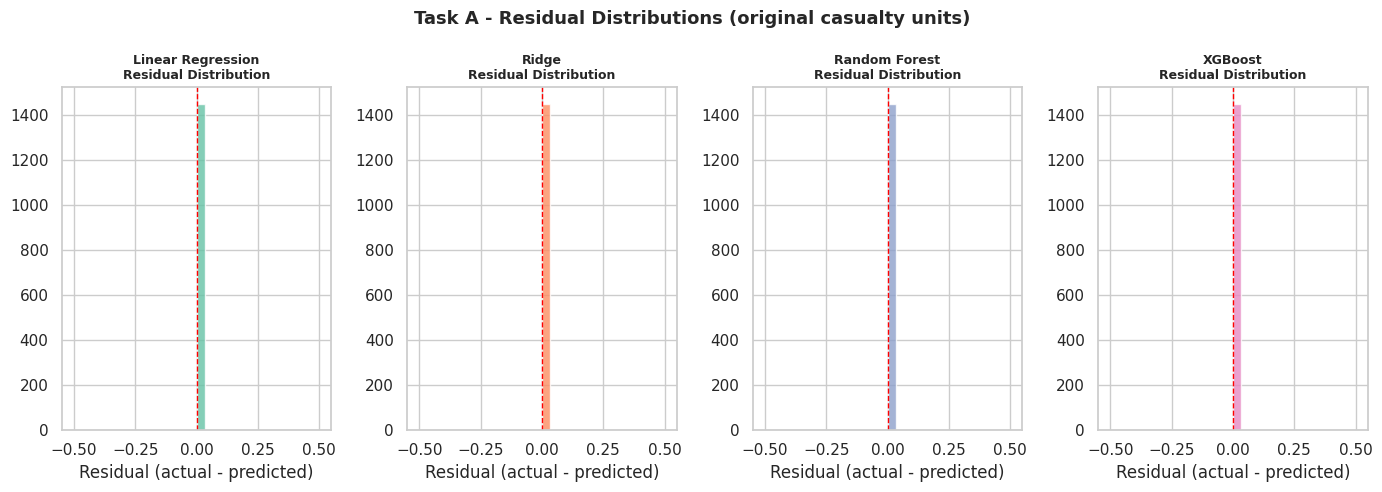

In [10]:
# Residual distributions for Task A models
fig, axes = plt.subplots(1, len(reg['task_a']['results']), figsize=tuple(NB_CONFIG['figsize_wide']))
palette = sns.color_palette(NB_CONFIG['palette'], len(reg['task_a']['results']))
y_true = reg['task_a']['y_test_orig']

for ax, ((model_name, r), color) in zip(
    axes, zip(reg['task_a']['results'].items(), palette, strict=False), strict=False
):
    residuals = y_true - r['y_pred_orig']
    ax.hist(residuals, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{model_name}\nResidual Distribution', fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual (actual - predicted)')

fig.suptitle('Task A - Residual Distributions (original casualty units)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 Collision Frequency Trend (Task B)

Trend slope:     -0.1381 collisions/month
R2:              0.0948
p-value:         0.0000
Direction:       decreasing (statistically significant at p<0.05)


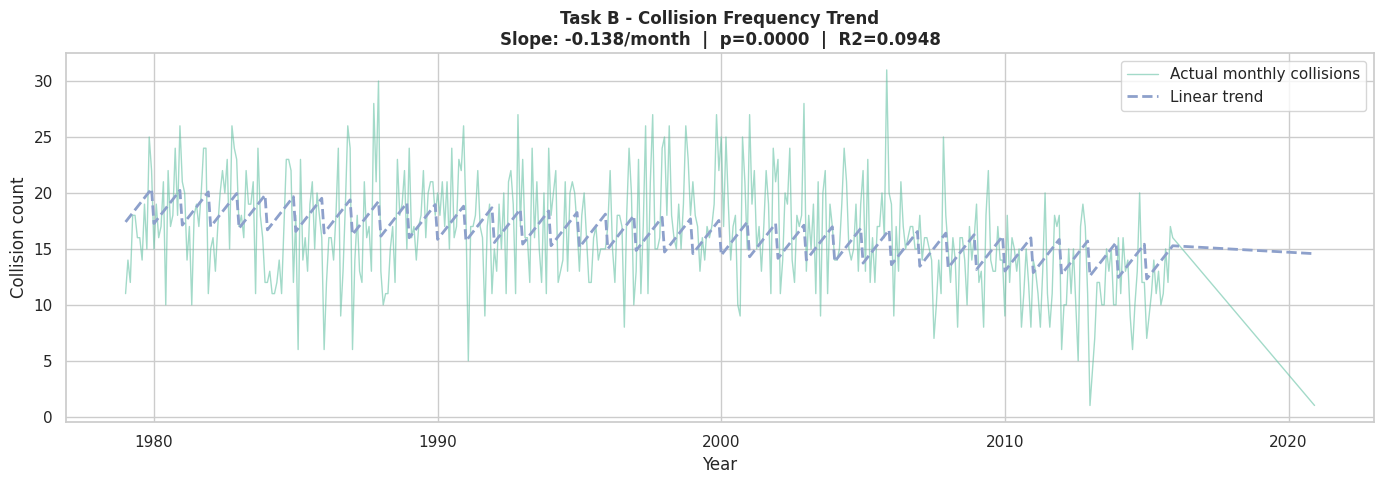

In [11]:
tb = reg['task_b']
print(f'Trend slope:     {tb["slope"]:.4f} collisions/month')
print(f'R2:              {tb["r_squared"]:.4f}')
print(f'p-value:         {tb["p_value"]:.4f}')
direction = 'increasing' if tb['slope'] > 0 else 'decreasing'
sig       = 'statistically significant' if tb['p_value'] < 0.05 else 'not statistically significant'
print(f'Direction:       {direction} ({sig} at p<0.05)')

monthly = tb['monthly_df']
fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_wide']))
palette = sns.color_palette(NB_CONFIG['palette'])
ax.plot(monthly['time_index'], monthly['collision_count'],
        alpha=0.6, linewidth=1, color=palette[0], label='Actual monthly collisions')
ax.plot(monthly['time_index'], tb['y_trend_pred'],
        linewidth=2, linestyle='--', color=palette[2], label='Linear trend')
ax.set_xlabel('Year')
ax.set_ylabel('Collision count')
ax.set_title(
    f'Task B - Collision Frequency Trend\n'
    f'Slope: {tb["slope"]:.3f}/month  |  p={tb["p_value"]:.4f}  |  R2={tb["r_squared"]:.4f}',
    fontsize=12, fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.show()

## 5.4 Spatial Augmentation Effect (Task C vs Task A)

In [12]:
# Spatial augmentation delta: did adding easting/northing help?
comparison_c = reg['task_c']['comparison_df']
print('Task C vs Task A - spatial augmentation effect:')
comparison_c

Task C vs Task A - spatial augmentation effect:


,MAE,RMSE,R2
Model,,,
Random Forest (Task A),0.0,0.0,0.0
RF + Spatial,0.0,0.0,0.0
XGBoost (Task A),0.0,0.0,1.0
XGB + Spatial,0.0,0.0,1.0


---
# 6. Clustering Summary

Task A clustered collisions by road and environment conditions.
Task B clustered by geographic location to identify spatial hotspots.

## 6.1 KMeans Quality Metrics Across All k Values

In [13]:
# Silhouette and Davies-Bouldin across all KMeans variants
clust_rows = []
for k, sil, db in zip(
    unsup['task_a']['k_range'],
    unsup['task_a']['silhouettes'],
    unsup['task_a']['db_scores'],
    strict=False,
):
    clust_rows.append({
        'Task': 'A (risk features)',
        'k': k,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(db, 4),
        'Selected': k == unsup['task_a']['best_k'],
    })

for k, sil, db in zip(
    unsup['task_b']['k_range'],
    unsup['task_b']['silhouettes'],
    unsup['task_b']['db_scores'], 
    strict=False,
):
    clust_rows.append({
        'Task': 'B (spatial)',
        'k': k,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(db, 4),
        'Selected': k == unsup['task_b']['best_k'],
    })

clust_summary = pd.DataFrame(clust_rows).set_index(['Task', 'k'])
print('KMeans cluster quality metrics across all k values:')
clust_summary

KMeans cluster quality metrics across all k values:


Silhouette  Davies-Bouldin  Selected
Task              k                                      
A (risk features) 2      0.3889          1.6438     False
                  3      0.4170          1.3611     False
                  4      0.4488          1.0419     False
                  5      0.4858          0.9182     False
                  6      0.5438          0.8394     False
                  7      0.5826          0.8236     False
                  8      0.6112          0.8400      True
B (spatial)       2      0.8850          0.5079     False
                  3      0.9306          0.3812      True
                  4      0.9219          0.5751     False
                  5      0.9213          0.5836     False
                  6      0.9228          0.5716     False
                  7      0.9238          0.5688     False
                  8      0.9261          0.5851     False

## 6.2 DBSCAN Summary

In [14]:
# DBSCAN summary for both tasks
for task_key, task_label in [('task_a', 'Task A (risk features)'), ('task_b', 'Task B (spatial)')]:
    labels = unsup[task_key]['dbscan_labels']
    unique = sorted(set(labels))
    n_clusters = len([l for l in unique if l != -1])  # noqa: E741
    n_noise    = (labels == -1).sum() if -1 in labels else 0
    noise_pct  = n_noise / len(labels) * 100
    print(f'{task_label}:')
    print(f'  Clusters found: {n_clusters}')
    print(f'  Noise points:   {n_noise} ({noise_pct:.1f}%)')
    print()

Task A (risk features):
  Clusters found: 101
  Noise points:   353 (4.9%)

Task B (spatial):
  Clusters found: 6
  Noise points:   21 (0.3%)



## 6.3 Task A - Cluster Profiles

In [15]:
print(f'Task A - KMeans cluster profiles (k={unsup["task_a"]["best_k"]}):')
unsup['task_a']['cluster_profile']

Task A - KMeans cluster profiles (k=8):


,number_of_casualties,number_of_vehicles,speed_limit,road_type,weather_conditions,light_conditions,road_surface_conditions
cluster,,,,,,,
0,1.0,0.5,33.07,2.34,1.19,1.00,1.26
1,1.0,0.5,30.58,6.19,1.53,1.00,2.08
2,1.0,0.5,30.49,6.20,1.04,4.15,1.00
3,1.0,0.5,30.40,6.20,1.03,1.00,1.00
4,1.0,0.5,32.57,5.44,7.65,2.40,1.96
5,1.0,0.5,32.81,2.34,1.32,4.08,1.51
6,1.0,0.5,61.97,4.93,1.46,2.30,1.61
7,1.0,0.5,30.67,6.14,1.56,4.13,2.15


## 6.4 Task A - PCA 2D Cluster Visualization

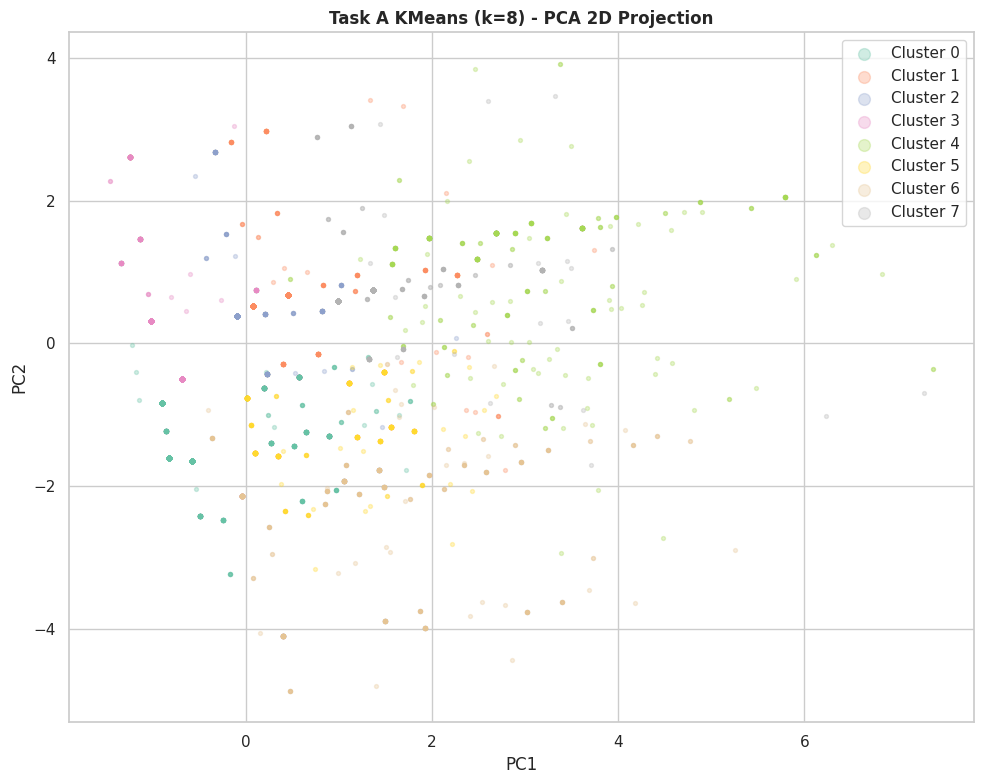

In [16]:
best_k_a    = unsup['task_a']['best_k']
labels_km_a = unsup['task_a']['kmeans_labels']
X_a_2d      = unsup['task_a']['pca_2d']
palette_a   = sns.color_palette(NB_CONFIG['palette'], best_k_a)

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))
for cl in range(best_k_a):
    mask = labels_km_a == cl
    ax.scatter(X_a_2d[mask, 0], X_a_2d[mask, 1],
               alpha=0.3, s=8, color=palette_a[cl], label=f'Cluster {cl}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Task A KMeans (k={best_k_a}) - PCA 2D Projection', fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 6.5 Task B - Geospatial Hotspot Map

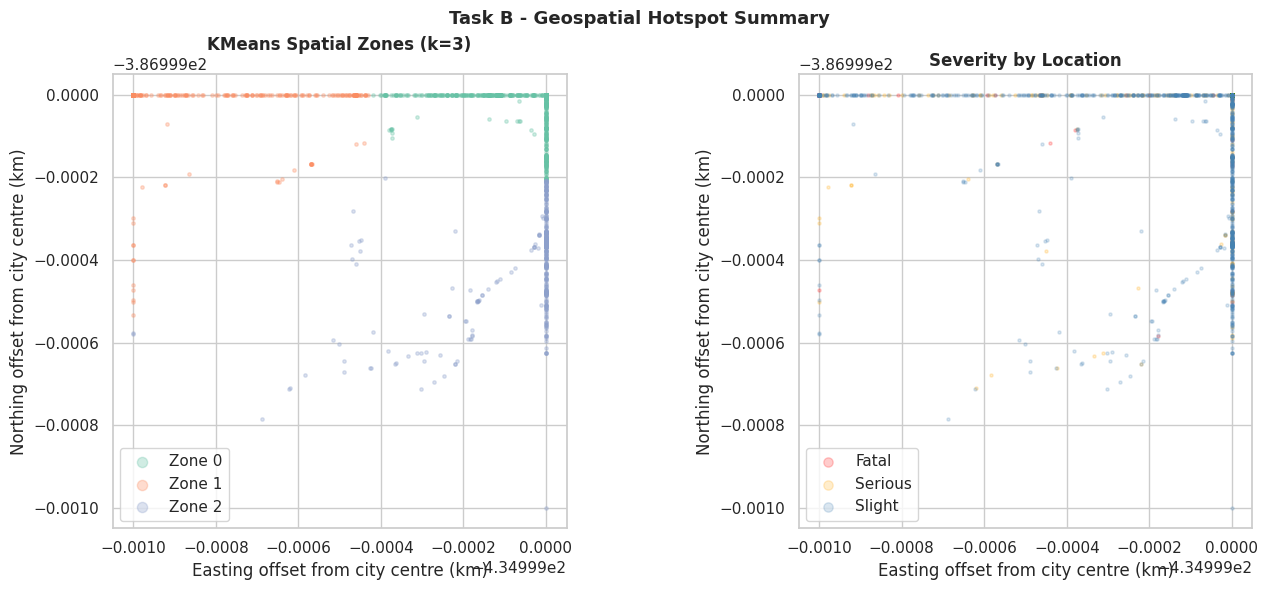

In [17]:
best_k_b    = unsup['task_b']['best_k']
labels_km_b = unsup['task_b']['kmeans_labels']
X_b         = unsup['task_b']['X_spatial']
severity_b  = unsup['task_b']['severity']
palette_b   = sns.color_palette(NB_CONFIG['palette'], best_k_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cl in range(best_k_b):
    mask = labels_km_b == cl
    axes[0].scatter(
        X_b['easting_km'].values[mask],
        X_b['northing_km'].values[mask],
        alpha=0.3, s=6, color=palette_b[cl], label=f'Zone {cl}'
    )
axes[0].set_xlabel('Easting offset from city centre (km)')
axes[0].set_ylabel('Northing offset from city centre (km)')
axes[0].set_title(f'KMeans Spatial Zones (k={best_k_b})', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_aspect('equal')

sev_colors = {1: 'red', 2: 'orange', 3: 'steelblue'}
for sev, color in sev_colors.items():
    mask = severity_b.values == sev
    axes[1].scatter(
        X_b['easting_km'].values[mask],
        X_b['northing_km'].values[mask],
        alpha=0.2, s=5, color=color,
        label=NB_CONFIG['severity_labels'][sev]
    )
axes[1].set_xlabel('Easting offset from city centre (km)')
axes[1].set_ylabel('Northing offset from city centre (km)')
axes[1].set_title('Severity by Location', fontweight='bold')
axes[1].legend(markerscale=3)
axes[1].set_aspect('equal')

fig.suptitle('Task B - Geospatial Hotspot Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 7. Responsible AI

This section audits the best-performing multiclass classifier for performance
disparities across subgroups, documents model limitations, and outlines
improvement strategies.

Responsible AI dimensions assessed:
- **Fairness:** does performance vary across urban/rural, light conditions, day of week?
- **Transparency:** documented modelling choices and known limitations
- **Safety:** Fatal class recall and implications for real-world deployment
- **Accountability:** improvement strategies and human oversight requirements

## 7.1 Best Model Selection

In [18]:
# Responsible AI bias audit
# Use the best multiclass model (highest macro F1) against subgroup slices of X_test
best_mc_model_name = s3['comparison_df']['Macro F1'].idxmax()
best_mc_model      = s3['results'][best_mc_model_name]['model']
scaler_mc          = s3['scaler']

X_test_mc = s3['X_test']
y_test_mc  = s3['y_test']

# Use scaled input for prediction (same as training)
y_pred_best = best_mc_model.predict(scaler_mc.transform(X_test_mc))

print(f'Bias audit model: {best_mc_model_name}')
print(f'Overall macro F1: {s3["results"][best_mc_model_name]["f1_macro"]:.4f}')

Bias audit model: Random Forest
Overall macro F1: 0.3502


## 7.2 Subgroup Performance Audit

In [19]:
# Subgroup performance across key fairness-relevant dimensions
subgroup_cols = ['urban_or_rural_area', 'light_conditions', 'day_of_week']
subgroup_results = []

for col in subgroup_cols:
    if col not in X_test_mc.columns:
        print(f'WARNING: {col} not in X_test - skipping')
        continue
    for val in sorted(X_test_mc[col].unique()):
        mask = X_test_mc[col].values == val
        if mask.sum() < 10:
            continue  # skip groups too small for reliable metrics
        y_true_sub = y_test_mc.values[mask]
        y_pred_sub = y_pred_best[mask]
        macro_f1   = f1_score(y_true_sub, y_pred_sub, average='macro', zero_division=0)
        subgroup_results.append({
            'Subgroup feature': col,
            'Value':            val,
            'n':                mask.sum(),
            'Macro F1':         round(macro_f1, 4), # type: ignore
        })

subgroup_df = pd.DataFrame(subgroup_results)
print(f'Subgroup performance audit ({best_mc_model_name}):')
subgroup_df

Subgroup performance audit (Random Forest):


,Subgroup feature,Value,n,Macro F1
0,light_conditions,1,1032,0.2954
1,light_conditions,4,381,0.3453
2,light_conditions,6,15,0.4886
3,light_conditions,7,15,0.5500
4,day_of_week,1,141,0.3037
5,day_of_week,2,192,0.2815
6,day_of_week,3,226,0.4227
7,day_of_week,4,231,0.2753
8,day_of_week,5,208,0.3065
9,day_of_week,6,224,0.2610


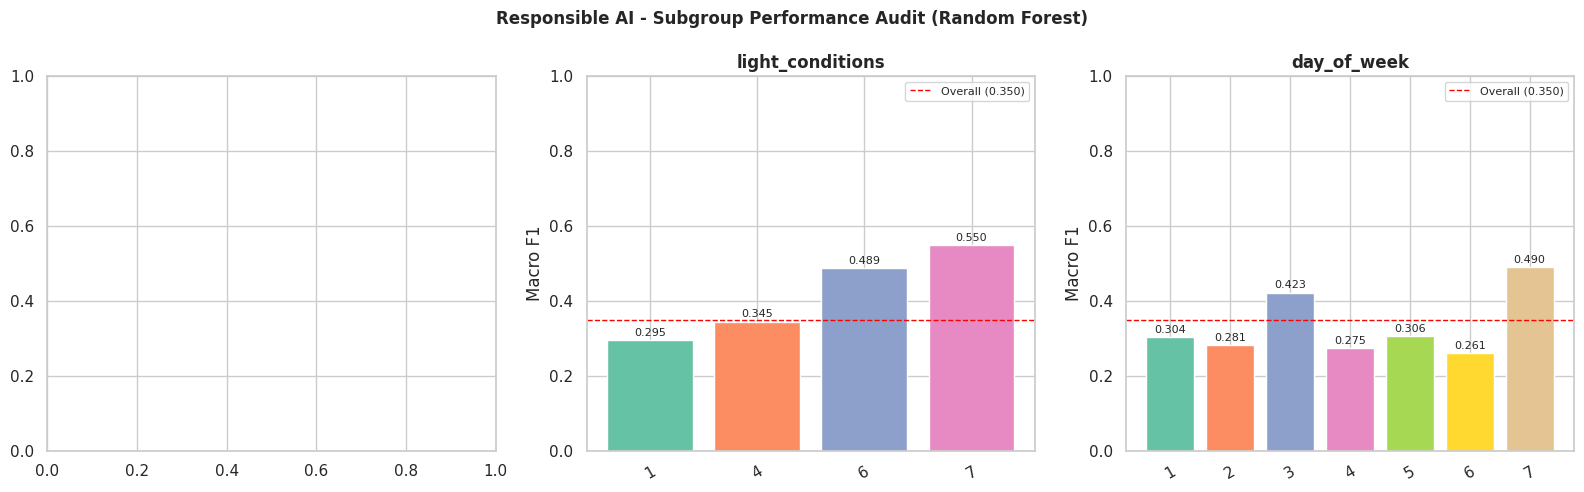

In [20]:
fig, axes = plt.subplots(1, len(subgroup_cols), figsize=(16, 5))
palette = sns.color_palette(NB_CONFIG['palette'])

for ax, col in zip(axes, subgroup_cols, strict=False):
    sub = subgroup_df[subgroup_df['Subgroup feature'] == col].sort_values('Value')
    if sub.empty:
        continue
    bars = ax.bar([str(v) for v in sub['Value']], sub['Macro F1'],
                  color=palette[:len(sub)], edgecolor='white')
    overall_f1 = s3['results'][best_mc_model_name]['f1_macro']
    ax.axhline(overall_f1, color='red', linestyle='--', linewidth=1, label=f'Overall ({overall_f1:.3f})')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sub['Macro F1'], strict=False):
        ax.annotate(f'{val:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

fig.suptitle(f'Responsible AI - Subgroup Performance Audit ({best_mc_model_name})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Responsible AI findings - print a structured summary
overall_f1 = s3['results'][best_mc_model_name]['f1_macro']

print('=== Responsible AI Summary ===')
print()
print(f'Model audited: {best_mc_model_name} (multiclass, collision_severity)')
print(f'Overall macro F1: {overall_f1:.4f}')
print()

for col in subgroup_cols:
    sub = subgroup_df[subgroup_df['Subgroup feature'] == col]
    if sub.empty:
        continue
    max_row = sub.loc[sub['Macro F1'].idxmax()]
    min_row = sub.loc[sub['Macro F1'].idxmin()]
    gap = max_row['Macro F1'] - min_row['Macro F1']
    print(f'{col}:')
    print(f'  Best subgroup:  value={max_row["Value"]} F1={max_row["Macro F1"]:.4f} (n={max_row["n"]})')
    print(f'  Worst subgroup: value={min_row["Value"]} F1={min_row["Macro F1"]:.4f} (n={min_row["n"]})')
    print(f'  Performance gap: {gap:.4f}')
    print()

=== Responsible AI Summary ===

Model audited: Random Forest (multiclass, collision_severity)
Overall macro F1: 0.3502

light_conditions:
  Best subgroup:  value=7 F1=0.5500 (n=15)
  Worst subgroup: value=1 F1=0.2954 (n=1032)
  Performance gap: 0.2546

day_of_week:
  Best subgroup:  value=7 F1=0.4897 (n=230)
  Worst subgroup: value=6 F1=0.2610 (n=224)
  Performance gap: 0.2287



## 7.3 Error Analysis and Improvement Strategies

In [22]:
# This cell is intentionally markdown-rendered via print for notebook display
improvements = """
=== Error Analysis and Improvement Strategies ===

CLASSIFICATION
--------------
Ceiling factor 1 - Fatal class sparsity:
  Only ~93 Fatal records in the full dataset. Even after SMOTE, synthetic Fatal
  samples are interpolations of a very small real-world pool. Models trained on
  synthetic minority samples may not generalise to genuinely novel Fatal patterns.

Ceiling factor 2 - Class overlap:
  Serious and Slight collisions share many feature values (similar road types,
  weather, time of day). The decision boundary between them is inherently noisy.

What was tried and its effect:
  - SMOTE: improved Fatal recall over class_weight-only baseline
  - GridSearchCV: marginal improvement over default hyperparameters on this dataset
  - XGBoost boosting: typically outperforms RF on tabular data but gap may be small
    given the low feature count

What would help further:
  - Additional engineered features (e.g. speed_limit x road_type interaction)
  - SHAP analysis to identify which features drive Fatal misclassifications
  - Threshold tuning: lower the classification threshold for Fatal to trade
    precision for recall (appropriate given the safety context)
  - Larger dataset: more Fatal records would reduce reliance on synthetic samples

REGRESSION
----------
  number_of_casualties has very low variance (modal value = 1, max ~10).
  R2 will be low regardless of model quality - this is a property of the target
  distribution, not a modelling failure. MAE and RMSE in original units are
  the more meaningful metrics here.

CLUSTERING
----------
  DBSCAN parameter sensitivity: eps and min_samples were taken from config
  without tuning. A k-distance plot would allow principled eps selection.
  Results should be treated as exploratory rather than definitive.

RESPONSIBLE AI
--------------
  Performance disparities across subgroups (urban/rural, light conditions)
  reflect real-world data imbalance rather than model bias per se - there are
  simply fewer Fatal collisions in some subgroups. This should be documented
  clearly if the model were to be deployed for real-world decision support.
  Model predictions should not be used to allocate resources without human
  oversight, particularly for high-severity classifications.
"""

print(improvements)


=== Error Analysis and Improvement Strategies ===

CLASSIFICATION
--------------
Ceiling factor 1 - Fatal class sparsity:
  Only ~93 Fatal records in the full dataset. Even after SMOTE, synthetic Fatal
  samples are interpolations of a very small real-world pool. Models trained on
  synthetic minority samples may not generalise to genuinely novel Fatal patterns.

Ceiling factor 2 - Class overlap:
  Serious and Slight collisions share many feature values (similar road types,
  weather, time of day). The decision boundary between them is inherently noisy.

What was tried and its effect:
  - SMOTE: improved Fatal recall over class_weight-only baseline
  - GridSearchCV: marginal improvement over default hyperparameters on this dataset
  - XGBoost boosting: typically outperforms RF on tabular data but gap may be small
    given the low feature count

What would help further:
  - Additional engineered features (e.g. speed_limit x road_type interaction)
  - SHAP analysis to identify which fe